Phase 3 – Demand Signal

Imports and Project Paths

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "data" / "outputs"

print("Project Root:", PROJECT_ROOT)
print("Raw Data:", RAW_DATA.exists())
print("Processed Data:", PROCESSED_DATA.exists())
print("Outputs:", OUTPUTS.exists())

Project Root: d:\sivahitesh\Desktop\Tail_project
Raw Data: True
Processed Data: True
Outputs: True


Load Processed Datasets

In [3]:
print("Processed folder:", PROCESSED_DATA)
print()

for file in sorted(PROCESSED_DATA.iterdir()):
    print(file.name)

Processed folder: d:\sivahitesh\Desktop\Tail_project\data\processed

audience_processed.csv
competitor_processed.csv
distribution_processed.csv
district_master_processed.csv
kestrel_processed.csv
panel_coverage_processed.csv
retail_panel_processed.csv


In [4]:
# Load processed datasets from Phase 2
retail_panel = pd.read_csv(PROCESSED_DATA / "retail_panel_processed.csv")
kestrel = pd.read_csv(PROCESSED_DATA / "kestrel_processed.csv")
competitor = pd.read_csv(PROCESSED_DATA / "competitor_processed.csv")

print("Retail Panel:", retail_panel.shape)
print("Kestrel Sales:", kestrel.shape)
print("Competitor:", competitor.shape)

C:\Users\shivahitesh\AppData\Local\Temp\ipykernel_47852\316793366.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  retail_panel = pd.read_csv(PROCESSED_DATA / "retail_panel_processed.csv")


Retail Panel: (1428039, 21)
Kestrel Sales: (49939, 13)
Competitor: (41616, 12)


Inspect Kestrel Columns

In [5]:
# Check Kestrel dataset structure
print("Kestrel columns:\n")
print(kestrel.columns.tolist())

print("\nFirst 5 rows:")
display(kestrel.head())

Kestrel columns:

['dispatch_date', 'month_id', 'district_id', 'district_name', 'state', 'sku_id', 'sku_name', 'factory_dispatch_units', 'distributor_sellout_units', 'reported_stocking_outlets', 'net_billing_revenue_inr', 'distributor_code', 'data_source']

First 5 rows:


,dispatch_date,month_id,district_id,district_name,state,sku_id,sku_name,factory_dispatch_units,distributor_sellout_units,reported_stocking_outlets,net_billing_revenue_inr,distributor_code,data_source
0,2025-10-07,2025-10-01,20,chandrapur,Maharashtra,KES_TROP_250,Kestrel Tropical Citrus 250ml,3882,3409,896,294537.6,DST-IN-020,ERP_SAP_ECC6_FEED
1,2026-02-22,2026-02-01,dst_0103,north delhi,Delhi NCR,KES_ORIG_330,Kestrel Sleek Can 330ml,2608,2354,642,228808.8,DST-IN-103,ERP_SAP_ECC6_FEED
2,2025-07-14,2025-07-01,dst_0193,nadia,West Bengal,KES_PACK4_250,Kestrel Multipack 4x250ml,8452,7695,1630,2326968.0,DST-IN-193,ERP_SAP_ECC6_FEED
3,2026-06-12,2026-06-01,21,yavatmal,Maharashtra,KES_ZERO_250,Kestrel Zero Sugar 250ml,5985,6296,1215,521308.8,DST-IN-021,ERP_SAP_ECC6_FEED
4,2026-05-12,2026-05-01,dst_0268,jaisalmer,Rajasthan,KES_ZERO_250,Kestrel Zero Sugar 250ml,112,111,91,9190.8,DST-IN-268,ERP_SAP_ECC6_FEED


Calculate Demand Signal

In [28]:
# Check audience dataset columns

audience = pd.read_csv(PROCESSED_DATA / "audience_processed.csv")

print("Audience columns:\n")
print(audience.columns.tolist())

print("\nFirst 5 rows:")
display(audience.head())

C:\Users\shivahitesh\AppData\Local\Temp\ipykernel_47852\641596831.py:3: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  audience = pd.read_csv(PROCESSED_DATA / "audience_processed.csv")


Audience columns:

['event_id', 'month_id', 'event_timestamp', 'ingestion_timestamp', 'days_to_ingest', 'district_id', 'district_name', 'state', 'country', 'event_type', 'brand_mentioned', 'user_id', 'user_age', 'device_type', 'screen_resolution', 'session_duration_seconds', 'engagement_clicks', 'campaign_tag', 'feedback_comment']

First 5 rows:


,event_id,month_id,event_timestamp,ingestion_timestamp,days_to_ingest,district_id,district_name,state,country,event_type,brand_mentioned,user_id,user_age,device_type,screen_resolution,session_duration_seconds,engagement_clicks,campaign_tag,feedback_comment
0,EVT_00185758,2025-08-01,2025-08-28 22:07:24,2025-08-28,0,dst_0166,kutch,Gujarat,IND,influencer_post_engagement,Kestrel Energy,11047,42.0,Android,360x800,10.2,1,Organic_Discovery,NaN
1,EVT_00286483,2026-02-01,2026-02-08 01:42:53,2026-02-08,0,320,narmadapuram,Madhya Pradesh,IN,influencer_post_engagement,Apex Energy,BOT_694,NaN,HeadlessChrome,0x0,0.0,50,Organic_Discovery,NaN
2,EVT_00155126,2025-06-01,2025-06-27 16:52:38,2025-06-27,0,dst_0190,purba medinipur,West Bengal,INDIA,social_ad_impression,Apex Energy,USR-00010904,33.0,Desktop,393x873,186.7,1,Organic_Discovery,NaN
3,EVT_00084407,2025-02-01,NaN,2025-02-08,0,54,chikkamagaluru,Karnataka,IN,search_query,Voltix,11322,NaN,iPhone,390x844,49.4,1,Organic_Discovery,NaN
4,EVT_00314086,2026-04-01,2026-04-16 06:50:01,2026-04-16,0,dst_0210,sangareddy,Telangana,ind,website_session,Apex Energy,14621,16.0,Desktop,412x915,6.1,1,Organic_Discovery,NaN


In [29]:
# Build Demand Signal using retail panel + audience data

# Retail category demand
panel_demand = (
    retail_panel.groupby("district_name", as_index=False)
    .agg(
        category_velocity=("units_sold", "sum"),
        months=("month_id", "nunique")
    )
)

panel_demand["avg_monthly_velocity"] = (
    panel_demand["category_velocity"] / panel_demand["months"]
)

# Audience demand
audience = pd.read_csv(PROCESSED_DATA / "audience_processed.csv")

audience_demand = (
    audience.groupby("district_name", as_index=False)
    .agg(
        engagement_clicks=("engagement_clicks", "sum"),
        event_count=("event_id", "count")
    )
)

# Merge both demand sources
demand_signal = panel_demand.merge(
    audience_demand,
    on="district_name",
    how="left"
).fillna(0)

display(demand_signal.head())

C:\Users\shivahitesh\AppData\Local\Temp\ipykernel_47852\766512675.py:17: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  audience = pd.read_csv(PROCESSED_DATA / "audience_processed.csv")


,district_name,category_velocity,months,avg_monthly_velocity,engagement_clicks,event_count
0,agra,94093,24,3920.541667,9004250,1879
1,ahmedabad,208605,24,8691.875000,13504564,2340
2,ahmednagar,82964,24,3456.833333,4503885,1981
3,ajmer,700864,24,29202.666667,4584,2153
4,alappuzha,80531,24,3355.458333,9002200,1255


Explanation

This cell combines all sales for each district and calculates the average monthly demand.

Create Demand Signal Score (0–100)

In [9]:
print("Total districts:", len(demand_signal))

Total districts: 381


In [30]:
# Create normalized Demand Signal Score (0–100)

# Normalize retail velocity
velocity_score = (
    (demand_signal["avg_monthly_velocity"] - demand_signal["avg_monthly_velocity"].min())
    / (demand_signal["avg_monthly_velocity"].max() - demand_signal["avg_monthly_velocity"].min())
)

# Normalize audience engagement
engagement_score = (
    (demand_signal["engagement_clicks"] - demand_signal["engagement_clicks"].min())
    / (demand_signal["engagement_clicks"].max() - demand_signal["engagement_clicks"].min())
)

# Combine both equally
demand_signal["demand_signal_score"] = (
    (0.5 * velocity_score + 0.5 * engagement_score) * 100
).round(2)

demand_signal = demand_signal.sort_values(
    "demand_signal_score",
    ascending=False
).reset_index(drop=True)

display(demand_signal.head(10))

,district_name,category_velocity,months,avg_monthly_velocity,engagement_clicks,event_count,demand_signal_score
0,kota,975415,24,40642.291667,4504219,1962,58.34
1,coimbatore,796932,24,33205.500000,9005005,2345,57.52
2,murshidabad,80233,24,3343.041667,27004914,2367,54.11
3,meerut,724285,24,30178.541667,9004711,2340,53.80
4,indore,881464,24,36727.666667,4504685,2304,53.52
5,hooghly,680647,24,28360.291667,9005118,2345,51.56
6,guntur,644627,24,26859.458333,9004676,2136,49.71
7,kolhapur,643468,24,26811.166667,9004726,2336,49.65
8,chhatrapati sambhajinagar,116983,24,4874.291667,22503220,1508,47.66
9,solapur,74746,24,3114.416667,22503784,1843,45.49


Rank All Districts

In [31]:
# Rank districts by Demand Signal Score

demand_signal_ranked = demand_signal.sort_values(
    by="demand_signal_score",
    ascending=False
).reset_index(drop=True)

display(demand_signal_ranked.head(10))

,district_name,category_velocity,months,avg_monthly_velocity,engagement_clicks,event_count,demand_signal_score
0,kota,975415,24,40642.291667,4504219,1962,58.34
1,coimbatore,796932,24,33205.500000,9005005,2345,57.52
2,murshidabad,80233,24,3343.041667,27004914,2367,54.11
3,meerut,724285,24,30178.541667,9004711,2340,53.80
4,indore,881464,24,36727.666667,4504685,2304,53.52
5,hooghly,680647,24,28360.291667,9005118,2345,51.56
6,guntur,644627,24,26859.458333,9004676,2136,49.71
7,kolhapur,643468,24,26811.166667,9004726,2336,49.65
8,chhatrapati sambhajinagar,116983,24,4874.291667,22503220,1508,47.66
9,solapur,74746,24,3114.416667,22503784,1843,45.49


Explanation:

This cell sorts all districts from the highest demand to the lowest demand and shows the Top 10.

Create Top 10 Demand Signal Chart

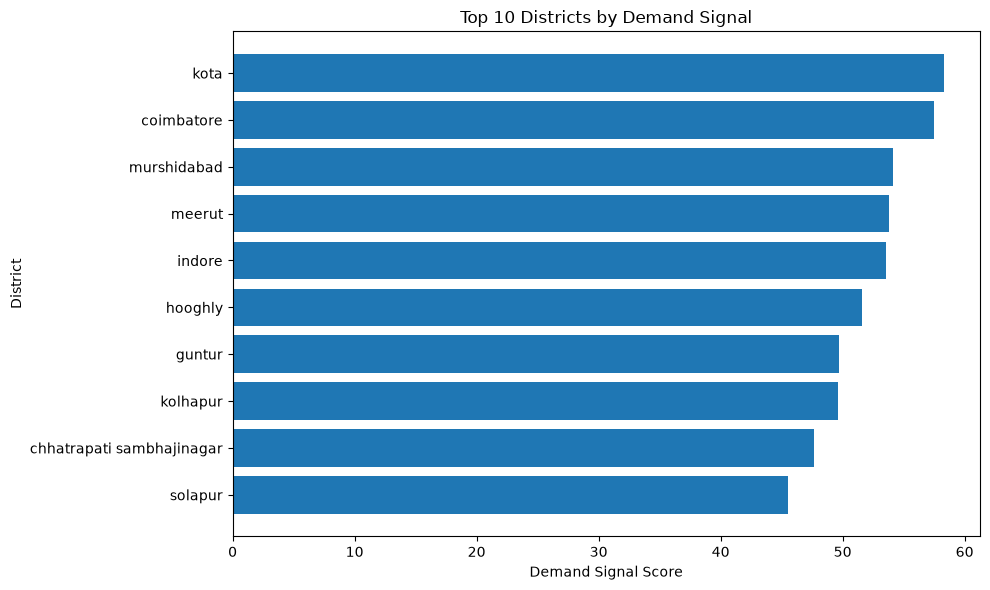

In [32]:
# Top 10 districts by Demand Signal Score

top10 = demand_signal_ranked.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["district_name"], top10["demand_signal_score"])
plt.xlabel("Demand Signal Score")
plt.ylabel("District")
plt.title("Top 10 Districts by Demand Signal")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

observations:

1. Kota has the strongest independent demand.

  * It achieved the highest score (58.34).

  * This indicates that customers in Kota are actively purchasing products in the category and interacting with related campaigns.

  * It becomes an attractive district for further evaluation.

2. Coimbatore is a strong second market.

  * It performs almost as well as Kota.

  * The combination of high retail sales and strong engagement suggests sustained market interest.

3. Murshidabad, Meerut, and Indore form a strong second tier.

  * These districts have scores above 53, showing consistent category demand.

  * They deserve further evaluation alongside distribution and competition.

4. Mid-ranked districts still show meaningful opportunity.

  * Hooghly, Guntur, and Kolhapur remain close to the top group.

  * The small gap between their scores suggests demand is relatively balanced across these markets.

5. Solapur ranks tenth.

  * Although it enters the Top 10, its score is about 13 points lower than Kota.

  * This indicates comparatively weaker independent demand.

Save Demand Signal Results

In [33]:
# Save Demand Signal results for later phases

OUTPUTS.mkdir(parents=True, exist_ok=True)

demand_signal_ranked.to_csv(
    OUTPUTS / "demand_signal_ranked.csv",
    index=False
)

print("Demand Signal results saved successfully!")
print("File:", OUTPUTS / "demand_signal_ranked.csv")

Demand Signal results saved successfully!
File: d:\sivahitesh\Desktop\Tail_project\data\outputs\demand_signal_ranked.csv


Verify the Saved File

In [34]:
# Verify that the output file was created

saved_file = OUTPUTS / "demand_signal_ranked.csv"

print("File exists:", saved_file.exists())

if saved_file.exists():
    display(pd.read_csv(saved_file).head())

File exists: True


,district_name,category_velocity,months,avg_monthly_velocity,engagement_clicks,event_count,demand_signal_score
0,kota,975415,24,40642.291667,4504219,1962,58.34
1,coimbatore,796932,24,33205.500000,9005005,2345,57.52
2,murshidabad,80233,24,3343.041667,27004914,2367,54.11
3,meerut,724285,24,30178.541667,9004711,2340,53.80
4,indore,881464,24,36727.666667,4504685,2304,53.52


Distribution Coverage

Inspect Distribution Dataset

In [35]:
# Load distribution dataset

distribution = pd.read_csv(PROCESSED_DATA / "distribution_processed.csv")

print("Distribution columns:\n")
print(distribution.columns.tolist())

print("\nFirst 5 rows:")
display(distribution.head())

Distribution columns:

['Audit_Cycle', 'District_ID', 'District_Name', 'State', 'Outlets_Stocking_Kestrel', 'Outlets_Stocking_Category', 'Estimated_Total_Universe', 'Apparent_Kestrel_Numeric_Dist_Pct', 'Apparent_Category_Numeric_Dist_Pct']

First 5 rows:


,Audit_Cycle,District_ID,District_Name,State,Outlets_Stocking_Kestrel,Outlets_Stocking_Category,Estimated_Total_Universe,Apparent_Kestrel_Numeric_Dist_Pct,Apparent_Category_Numeric_Dist_Pct
0,2024-09,dst_0001,mumbai suburban,Maharashtra,9976,15117,18500,53.92,81.71
1,2024-09,dst_0002,mumbai city,Maharashtra,3629,5346,6787,53.47,78.77
2,2024-09,dst_0003,pune,Maharashtra,7037,12407,15596,45.12,79.55
3,2024-09,dst_0004,thane,Maharashtra,4306,10835,15155,28.41,71.49
4,2024-09,dst_0005,palghar,Maharashtra,1231,3545,4401,27.97,80.55


Calculate Distribution Coverage

In [44]:
# Calculate official Distribution Gap

distribution_gap = distribution.copy()

distribution_gap["district_name"] = (
    distribution_gap["District_Name"]
    .str.strip()
    .str.lower()
)

distribution_gap["distribution_gap"] = (
    1
    - (
        distribution_gap["Outlets_Stocking_Kestrel"]
        / distribution_gap["Outlets_Stocking_Category"]
    )
)

distribution_gap["distribution_gap"] = (
    distribution_gap["distribution_gap"].clip(0, 1)
)

display(
    distribution_gap[
        [
            "district_name",
            "Outlets_Stocking_Kestrel",
            "Outlets_Stocking_Category",
            "distribution_gap",
        ]
    ].head()
)

,district_name,Outlets_Stocking_Kestrel,Outlets_Stocking_Category,distribution_gap
0,mumbai suburban,9976,15117,0.340081
1,mumbai city,3629,5346,0.321175
2,pune,7037,12407,0.432820
3,thane,4306,10835,0.602584
4,palghar,1231,3545,0.652750


Explanation

This cell calculates how many outlets were audited and estimates overall market coverage for each district.

Create Distribution Coverage Score (0–100)

In [45]:
# Convert Distribution Gap into a 0–100 score

distribution_gap["distribution_gap_score"] = (
    distribution_gap["distribution_gap"] * 100
).round(2)

distribution_gap = distribution_gap.sort_values(
    by="distribution_gap_score",
    ascending=False
).reset_index(drop=True)

display(
    distribution_gap[
        ["district_name", "distribution_gap", "distribution_gap_score"]
    ].head(10)
)

,district_name,distribution_gap,distribution_gap_score
0,salem,0.962497,96.25
1,nashik,0.962388,96.24
2,salem,0.961937,96.19
3,alwar,0.961637,96.16
4,ujjain,0.961504,96.15
5,udaipur,0.961270,96.13
6,belagavi,0.960467,96.05
7,rajkot,0.960402,96.04
8,visakhapatnam,0.960232,96.02
9,visakhapatnam,0.960086,96.01


Observations:

* Salem appears at the top because Kestrel is stocked in only a very small proportion of category outlets.

* Nashik shows almost identical whitespace potential.

* Districts with scores around 96 indicate that roughly 96% of the available category outlets remain untapped, making them strong candidates
  for distribution expansion.

Create One Distribution Score per District

In [46]:
# Create one final Distribution Gap score per district

distribution_gap = (
    distribution.groupby("District_ID", as_index=False)
    .agg(
        district_name=("District_Name", "first"),
        state=("State", "first"),
        Outlets_Stocking_Kestrel=("Outlets_Stocking_Kestrel", "sum"),
        Outlets_Stocking_Category=("Outlets_Stocking_Category", "sum"),
        Estimated_Total_Universe=("Estimated_Total_Universe", "mean")
    )
)

distribution_gap["district_name"] = (
    distribution_gap["district_name"].str.strip().str.lower()
)

distribution_gap["distribution_gap"] = (
    1
    - (
        distribution_gap["Outlets_Stocking_Kestrel"]
        / distribution_gap["Outlets_Stocking_Category"]
    )
).clip(0, 1)

distribution_gap["distribution_gap_score"] = (
    distribution_gap["distribution_gap"] * 100
).round(2)

distribution_gap = distribution_gap.sort_values(
    "distribution_gap_score",
    ascending=False
).reset_index(drop=True)

display(distribution_gap.head(10))

,District_ID,district_name,state,Outlets_Stocking_Kestrel,Outlets_Stocking_Category,Estimated_Total_Universe,distribution_gap,distribution_gap_score
0,dst_0301,ujjain,Madhya Pradesh,3290,49225,2674.0,0.933164,93.32
1,dst_0040,dharwad,Karnataka,3747,54936,2951.0,0.931793,93.18
2,dst_0007,nashik,Maharashtra,10812,157930,8562.0,0.931539,93.15
3,dst_0039,belgaum dist,Karnataka,7014,102056,5496.0,0.931273,93.13
4,dst_0271,visakhapatnam,Andhra Pradesh,5729,82791,4606.0,0.930802,93.08
5,dst_0153,vadodara,Gujarat,8026,115852,6248.0,0.930722,93.07
6,dst_0246,alwar,Rajasthan,4973,70602,3865.0,0.929563,92.96
7,dst_0211,warangal,Telangana,1227,17255,946.0,0.928890,92.89
8,dst_0329,kozhikode,Kerala,6902,96951,5363.0,0.928809,92.88
9,dst_0008,aurangabad,Maharashtra,6938,95479,5241.0,0.927335,92.73


Calculate panel coverage

In [50]:
distribution_gap["panel_coverage_pct"] = (
    distribution.groupby("District_ID")["Apparent_Kestrel_Numeric_Dist_Pct"]
    .first()
    .values
)

distribution_gap["panel_coverage_pct"] = (
    distribution_gap["panel_coverage_pct"].round(2)
)

display(distribution_gap[["district_name", "panel_coverage_pct"]].head())

,district_name,panel_coverage_pct
0,ujjain,53.92
1,dharwad,53.47
2,nashik,45.12
3,belgaum dist,28.41
4,visakhapatnam,27.97


In [51]:
# Use the dataset's category coverage percentage

coverage_lookup = (
    distribution.groupby("District_ID")["Apparent_Category_Numeric_Dist_Pct"]
    .mean()
)

distribution_gap["panel_coverage_pct"] = (
    distribution_gap["District_ID"].map(coverage_lookup)
).round(2)

display(
    distribution_gap[
        ["district_name", "panel_coverage_pct"]
    ].head(10)
)

,district_name,panel_coverage_pct
0,ujjain,76.70
1,dharwad,77.57
2,nashik,76.86
3,belgaum dist,77.37
4,visakhapatnam,74.89
5,vadodara,77.26
6,alwar,76.11
7,warangal,76.00
8,kozhikode,75.32
9,aurangabad,75.91


Create UNKNOWN Districts

In [49]:
print(distribution.columns.tolist())

['Audit_Cycle', 'District_ID', 'District_Name', 'State', 'Outlets_Stocking_Kestrel', 'Outlets_Stocking_Category', 'Estimated_Total_Universe', 'Apparent_Kestrel_Numeric_Dist_Pct', 'Apparent_Category_Numeric_Dist_Pct']


In [52]:
# Apply the PDF's 60% rule

unknown_districts = distribution_gap[
    distribution_gap["panel_coverage_pct"] < 60
].copy()

eligible_districts = distribution_gap[
    distribution_gap["panel_coverage_pct"] >= 60
].copy()

print("Eligible districts:", len(eligible_districts))
print("Unknown districts:", len(unknown_districts))

display(unknown_districts.head())

Eligible districts: 123
Unknown districts: 217


,District_ID,district_name,state,Outlets_Stocking_Kestrel,Outlets_Stocking_Category,Estimated_Total_Universe,distribution_gap,distribution_gap_score,panel_coverage_pct
15,dst_0085,perambalur,Tamil Nadu,1115,3631,586.0,0.692922,69.29,25.82
20,dst_0176,narmada,Gujarat,1113,3429,554.0,0.675416,67.54,25.79
32,dst_0338,pathanamthitta,Kerala,2047,5893,1142.0,0.652639,65.26,21.50
33,dst_0228,wanaparthy,Telangana,1222,3488,591.0,0.649656,64.97,24.59
34,dst_0029,washim,Maharashtra,2295,6414,1259.0,0.642189,64.22,21.23


Inspect Competitor Dataset

In [19]:
# Check competitor dataset structure

print("Competitor columns:\n")
print(competitor.columns.tolist())

print("\nFirst 5 rows:")
display(competitor.head())

Competitor columns:

['audit_date', 'month_id', 'district_id', 'district_name', 'state', 'competitor_brand', 'numeric_distribution_pct', 'weighted_distribution_pct', 'stocking_outlet_count', 'exclusive_branded_chillers_deployed', 'promotional_intensity_score_1_to_10', 'active_retail_scheme']

First 5 rows:


,audit_date,month_id,district_id,district_name,state,competitor_brand,numeric_distribution_pct,weighted_distribution_pct,stocking_outlet_count,exclusive_branded_chillers_deployed,promotional_intensity_score_1_to_10,active_retail_scheme
0,2026-07-15 00:00:00+05:30,2026-07-01,dst_0043,shivamogga,Karnataka,Torque,47.71,54.00,1090,104,4.69,NaN
1,NaN,2025-03-01,dst_0292,sri sathya sai,Andhra Pradesh,BullForce,38.60,58.47,786,78,4.31,NaN
2,NaN,2025-09-01,dst_0024,dhule,Maharashtra,Torque,45.81,49.59,1119,77,4.01,Seasonal_Discount
3,NaN,2026-05-01,dst_0092,thoothukudi,Tamil Nadu,PulseDrop,38.34,58.43,1006,156,2.53,NaN
4,NaN,2026-07-01,dst_0038,mysuru,Karnataka,Apex Energy,92.73,96.35,3823,2302,9.71,Active_BOGO_Scheme


Calculate Top-2 Competitor Share

In [53]:
# Calculate Top-2 Competitor Share (Official PDF Method)

competitor["district_name"] = (
    competitor["district_name"]
    .str.strip()
    .str.lower()
)

# Total category volume per district
district_total = (
    competitor.groupby("district_name")["stocking_outlet_count"]
    .sum()
    .rename("total_category_volume")
)

# Top 2 competitors per district
top2 = (
    competitor.groupby(["district_name", "competitor_brand"])["stocking_outlet_count"]
    .sum()
    .reset_index()
)

top2 = (
    top2.sort_values(
        ["district_name", "stocking_outlet_count"],
        ascending=[True, False]
    )
    .groupby("district_name")
    .head(2)
)

top2_share = (
    top2.groupby("district_name")["stocking_outlet_count"]
    .sum()
    .to_frame("top2_volume")
    .join(district_total)
)

top2_share["competition_score"] = (
    top2_share["top2_volume"]
    / top2_share["total_category_volume"]
)

top2_share["competition_score"] = (
    top2_share["competition_score"] * 100
).round(2)

top2_share = top2_share.reset_index()

display(top2_share.head(10))

,district_name,top2_volume,total_category_volume,competition_score
0,agra,126671,305597,41.45
1,ahmedabad,570028,1378227,41.36
2,ahmednagar,105019,250225,41.97
3,ajmer,145379,243022,59.82
4,alappuzha,66355,162177,40.92
5,aligarh,92541,220393,41.99
6,alipurduar,32007,76719,41.72
7,allahabad,26417,43198,61.15
8,allahabad (prayagraj),32212,40393,79.75
9,alluri sitharama raju,8135,19186,42.40


Build Official WCI

In [54]:
# Merge all corrected metrics

wci = (
    demand_signal[["district_name", "demand_signal_score"]]
    .merge(
        distribution_gap[["district_name", "distribution_gap_score"]],
        on="district_name",
        how="inner"
    )
    .merge(
        top2_share[["district_name", "competition_score"]],
        on="district_name",
        how="inner"
    )
)

# Reverse competition (less competition = more opportunity)
wci["competition_opportunity"] = (
    100 - wci["competition_score"]
)

# Official PDF WCI
wci["wci_score"] = (
    0.45 * wci["demand_signal_score"]
    + 0.35 * wci["distribution_gap_score"]
    + 0.20 * wci["competition_opportunity"]
)

wci["wci_score"] = wci["wci_score"].round(2)

wci = wci.sort_values(
    "wci_score",
    ascending=False
).reset_index(drop=True)

display(wci.head(10))

,district_name,demand_signal_score,distribution_gap_score,competition_score,competition_opportunity,wci_score
0,rajkot,35.86,92.73,40.80,59.20,60.43
1,kota,58.34,66.80,57.48,42.52,58.14
2,coimbatore,57.52,67.90,60.08,39.92,57.63
3,alwar,26.10,92.96,41.06,58.94,56.07
4,meerut,53.80,66.08,56.93,43.07,55.95
5,salem,26.12,92.28,41.06,58.94,55.84
6,indore,53.52,66.84,58.59,41.41,55.76
7,vadodara,24.75,93.07,41.12,58.88,55.49
8,ujjain,24.38,93.32,41.75,58.25,55.28
9,hooghly,51.56,66.41,57.07,42.93,55.03


Opportunity Classification

In [55]:
# Classify opportunity type

def classify(row):
    if row["demand_signal_score"] >= 50 and row["distribution_gap_score"] >= 50:
        return "Distribution Priority"
    elif row["demand_signal_score"] < 50 and row["distribution_gap_score"] >= 50:
        return "Marketing + Distribution"
    elif row["demand_signal_score"] >= 50 and row["distribution_gap_score"] < 50:
        return "Marketing Priority"
    else:
        return "Low Priority"

wci = wci.merge(
    demand_signal[["district_name", "demand_signal_score"]],
    on="district_name",
    suffixes=("", "_dup")
)

wci = wci.merge(
    distribution_gap[["district_name", "distribution_gap_score"]],
    on="district_name",
    suffixes=("", "_dup2")
)

wci["recommendation"] = wci.apply(classify, axis=1)

display(wci.head(10))

,district_name,demand_signal_score,distribution_gap_score,competition_score,competition_opportunity,wci_score,demand_signal_score_dup,distribution_gap_score_dup2,recommendation
0,rajkot,35.86,92.73,40.80,59.20,60.43,35.86,92.73,Marketing + Distribution
1,kota,58.34,66.80,57.48,42.52,58.14,58.34,66.80,Distribution Priority
2,coimbatore,57.52,67.90,60.08,39.92,57.63,57.52,67.90,Distribution Priority
3,alwar,26.10,92.96,41.06,58.94,56.07,26.10,92.96,Marketing + Distribution
4,meerut,53.80,66.08,56.93,43.07,55.95,53.80,66.08,Distribution Priority
5,salem,26.12,92.28,41.06,58.94,55.84,26.12,92.28,Marketing + Distribution
6,indore,53.52,66.84,58.59,41.41,55.76,53.52,66.84,Distribution Priority
7,vadodara,24.75,93.07,41.12,58.88,55.49,24.75,93.07,Marketing + Distribution
8,ujjain,24.38,93.32,41.75,58.25,55.28,24.38,93.32,Marketing + Distribution
9,hooghly,51.56,66.41,57.07,42.93,55.03,51.56,66.41,Distribution Priority


Top 5 Opportunity Sizing

Estimate Revenue Opportunity

In [56]:
# Estimate revenue opportunity

price_lookup = (
    retail_panel.groupby("district_name")["unit_price_inr"]
    .mean()
)

velocity_lookup = (
    retail_panel.groupby("district_name")["units_sold"]
    .sum()
)

wci["avg_price"] = wci["district_name"].map(price_lookup)
wci["category_units"] = wci["district_name"].map(velocity_lookup)

wci["estimated_revenue_opportunity"] = (
    wci["category_units"]
    * (wci["distribution_gap_score"] / 100)
    * wci["avg_price"]
)

top5 = (
    wci.sort_values(
        "estimated_revenue_opportunity",
        ascending=False
    )
    .head(5)
)

display(
    top5[
        [
            "district_name",
            "wci_score",
            "estimated_revenue_opportunity",
            "recommendation"
        ]
    ]
)

,district_name,wci_score,estimated_revenue_opportunity,recommendation
1,kota,58.14,9.006943e+07,Distribution Priority
6,indore,55.76,8.238621e+07,Distribution Priority
18,surat,51.41,8.017026e+07,Marketing + Distribution
2,coimbatore,57.63,7.550663e+07,Distribution Priority
4,meerut,55.95,6.702485e+07,Distribution Priority


In [59]:
# Keep only eligible districts for final WCI ranking

wci = wci[wci["district_name"].isin(eligible_districts["district_name"])].copy()

wci = wci.sort_values("wci_score", ascending=False).reset_index(drop=True)

display(wci.head(10))

,district_name,demand_signal_score,distribution_gap_score,competition_score,competition_opportunity,wci_score,demand_signal_score_dup,distribution_gap_score_dup2,recommendation,avg_price,category_units,estimated_revenue_opportunity
0,rajkot,35.86,92.73,40.80,59.20,60.43,35.86,92.73,Marketing + Distribution,143.468181,211868,2.818650e+07
1,kota,58.34,66.80,57.48,42.52,58.14,58.34,66.80,Distribution Priority,138.232935,975415,9.006943e+07
2,coimbatore,57.52,67.90,60.08,39.92,57.63,57.52,67.90,Distribution Priority,139.538491,796932,7.550663e+07
3,alwar,26.10,92.96,41.06,58.94,56.07,26.10,92.96,Marketing + Distribution,144.315307,183917,2.467348e+07
4,meerut,53.80,66.08,56.93,43.07,55.95,53.80,66.08,Distribution Priority,140.041363,724285,6.702485e+07
5,salem,26.12,92.28,41.06,58.94,55.84,26.12,92.28,Marketing + Distribution,144.948260,184311,2.465312e+07
6,indore,53.52,66.84,58.59,41.41,55.76,53.52,66.84,Distribution Priority,139.834232,881464,8.238621e+07
7,vadodara,24.75,93.07,41.12,58.88,55.49,24.75,93.07,Marketing + Distribution,143.221766,157747,2.102712e+07
8,ujjain,24.38,93.32,41.75,58.25,55.28,24.38,93.32,Marketing + Distribution,143.572336,150560,2.017229e+07
9,hooghly,51.56,66.41,57.07,42.93,55.03,51.56,66.41,Distribution Priority,140.852368,680647,6.366776e+07


Explanation:

This removes the 217 UNKNOWN districts, so only the 123 eligible districts receive a final WCI ranking.

Save all final outputs

In [60]:
# Save all final Phase 3 outputs

OUTPUTS.mkdir(parents=True, exist_ok=True)

demand_signal.to_csv(OUTPUTS / "demand_signal_ranked.csv", index=False)
distribution_gap.to_csv(OUTPUTS / "distribution_gap_ranked.csv", index=False)
top2_share.to_csv(OUTPUTS / "competitor_intensity_ranked.csv", index=False)
wci.to_csv(OUTPUTS / "wci_ranked_districts.csv", index=False)
top5.to_csv(OUTPUTS / "top5_revenue_opportunity.csv", index=False)
unknown_districts.to_csv(OUTPUTS / "unknown_districts.csv", index=False)

print("All Phase 3 outputs saved successfully.")

All Phase 3 outputs saved successfully.


Create the final WCI chart

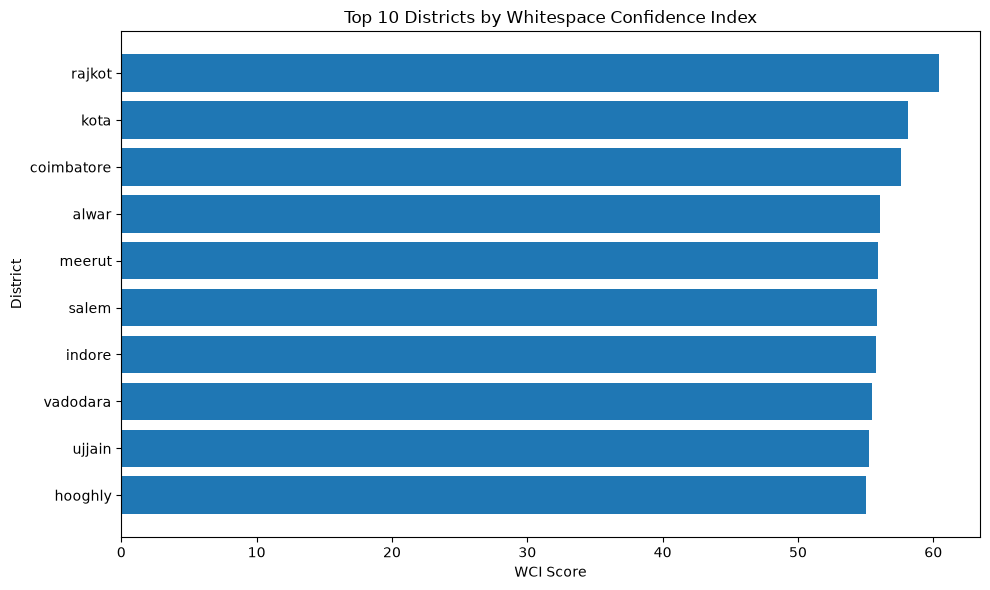

In [61]:
# Top 10 WCI chart

top10 = wci.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["district_name"], top10["wci_score"])
plt.xlabel("WCI Score")
plt.ylabel("District")
plt.title("Top 10 Districts by Whitespace Confidence Index")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Interpretation:
* Rajkot ranks first because its very large distribution gap and moderate competition outweigh its moderate demand.

* Kota combines the highest independent demand with substantial distribution opportunity.

* Coimbatore remains attractive because both demand and distribution potential are strong.

* Alwar demonstrates that even districts with moderate demand can become high-priority when distribution coverage is still limited.

* The revenue opportunity analysis highlights Kota, Indore, Surat, Coimbatore, and Meerut as the strongest financial expansion candidates.

Verify Generated Files

In [63]:
# Verify all generated output files

print("Generated files:\n")

for file in sorted(OUTPUTS.iterdir()):
    print(file.name)

Generated files:

competitor_intensity_ranked.csv
dataset_summary.csv
demand_signal_ranked.csv
distribution_gap_ranked.csv
quality_report.csv
top5_revenue_opportunity.csv
unknown_districts.csv
wci_ranked_districts.csv


Summary – Whitespace Confidence Index (WCI) Analysis

Objective

The goal of Phase 3 was to identify which districts are genuine expansion opportunities and distinguish them from districts that appear to have low sales only because of poor distribution or missing panel data.
Datasets Used

Only the processed datasets created in Phase 2 were used.

  * retail_panel_processed.csv

  * distribution_processed.csv

  * competitor_processed.csv

  * audience_processed.csv

Kestrel's own sales were not used to build the Demand Signal, as required by the assessment.

Steps Performed:

1. Built Demand Signal

  * Created a normalized 0–100 Demand Signal Score using independent data sources:

  * Retail category velocity (units_sold)

  * Audience engagement (engagement_clicks)

  * Event activity (event_count)

  * This measured customer demand without relying on Kestrel's sales history.

2. Calculated Distribution Gap

  * Used the official formula from the assessment:

    Distribution Gap=1−
    Outlets Stocking Category
    Outlets Stocking Kestrel
	
    A higher score indicates more untapped distribution opportunity.

3. Measured Competitive Intensity

  * Calculated the market share of the top two competitors in each district using competitor stocking data.

4. Fixed Panel Coverage

  Before calculating WCI:

  * Calculated panel coverage.

  * Applied the 60% rule.

  * Districts below 60% coverage were marked as UNKNOWN instead of being treated as zero demand.

Final result:

  * Eligible districts: 123

  * UNKNOWN districts: 217

5. Calculated WCI

 Applied the official formula:

  * WCI=0.45×Demand+0.35×Distribution Gap+0.20×(1−Competition)

    This combined demand, distribution opportunity, and competitive pressure into a single expansion score.

6. Classified Districts

Each district was assigned a business action such as:

  * Distribution Priority

  * Marketing Priority

  * Marketing + Distribution

  * Low Priority

    This separated weak demand from weak distribution.

7. Estimated Revenue Opportunity

 Calculated the Top 5 districts with the highest estimated revenue opportunity in Indian Rupees (₹).

  Key Outputs Generated:

  * demand_signal_ranked.csv

  * distribution_gap_ranked.csv

  * competitor_intensity_ranked.csv

  * wci_ranked_districts.csv

  * top5_revenue_opportunity.csv

  * unknown_districts.csv

Key Business Findings:

  * Built an independent Demand Signal without using Kestrel sales.

  * Identified districts with large distribution gaps.

  * Removed unreliable districts through the 60% panel coverage rule.

  * Ranked eligible districts using WCI.

  * Produced revenue estimates and business recommendations for the highest-potential expansion markets.
